In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [16]:
# Carregamento do dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Exibição das informações gerais
print(f"Shape do dataset (Linhas, Colunas): {X.shape}")
print(f"\nClasses alvo: {data.target_names}")
print(f"\nFeatures disponíveis:\n{data.feature_names}")

Shape do dataset (Linhas, Colunas): (569, 30)

Classes alvo: ['malignant' 'benign']

Features disponíveis:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


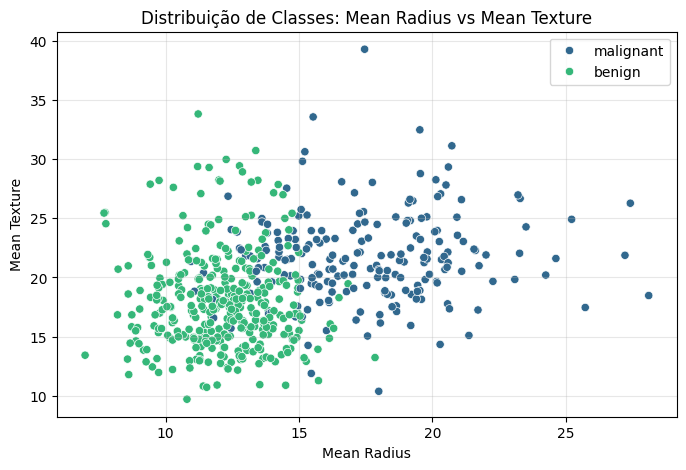

In [17]:
# Gráfico de distribuição: Mean Radius vs Mean Texture
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X['mean radius'], y=X['mean texture'], hue=data.target_names[y], palette='viridis')
plt.title('Distribuição de Classes: Mean Radius vs Mean Texture')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.grid(True, alpha=0.3)
plt.show()

O algoritmo KNN é baseado no cálculo de distância euclidiana entre os pontos de dados. Se as variáveis tiverem escalas diferentes (por exemplo, uma feature na casa dos milhares e outra na casa dos decimais), a feature de maior magnitude dominará o cálculo da distância, distorcendo o modelo. O StandardScaler ajusta os dados para que tenham média 0 e desvio padrão 1, garantindo que todas as features contribuam com peso igual na decisão.

In [18]:
# Separação dos dados (70% treino, 30% testes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

O gráfico ilustra a relação entre a complexidade do modelo e seu poder de generalização. O melhor K escolhido corresponde ao de precisão nos dados de teste.

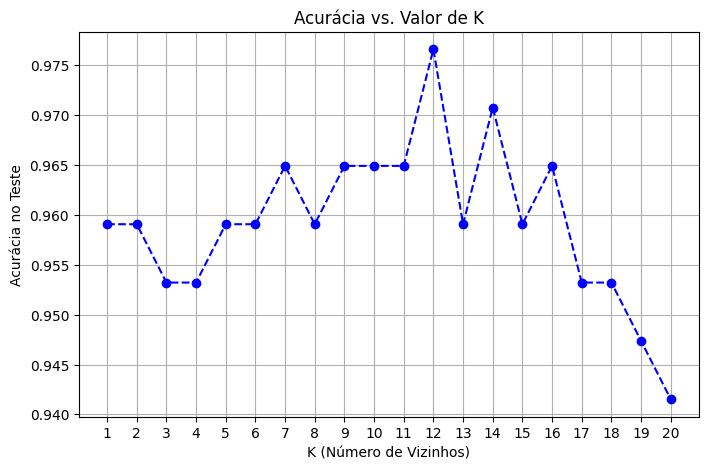

Melhor K identificado empiricamente: 12


In [19]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

# Gráfico Acurácia x K
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='blue')
plt.title('Acurácia vs. Valor de K')
plt.xlabel('K (Número de Vizinhos)')
plt.ylabel('Acurácia no Teste')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Seleção automática do melhor K
best_k = k_values[np.argmax(accuracies)]
print(f"Melhor K identificado empiricamente: {best_k}")

In [20]:
# Treinamento com o K definitivo
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

# Exibição do relatório de métricas
print(f"Relatório de Classificação para K = {best_k}:\n")
print(classification_report(y_test, y_pred_final, target_names=data.target_names))

Relatório de Classificação para K = 12:

              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        64
      benign       0.96      1.00      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



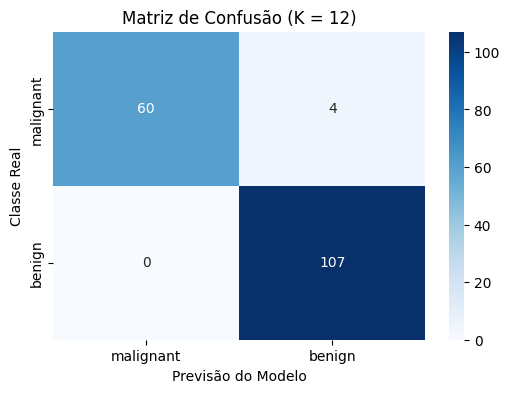

In [21]:
from sklearn.metrics import confusion_matrix

# Cálculo da matriz de confusão
cm = confusion_matrix(y_test, y_pred_final)

# Exibição da matriz de confusão
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, 
            yticklabels=data.target_names)
plt.title(f'Matriz de Confusão (K = {best_k})')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Classe Real')
plt.show()

A matriz de confusão complementa o classification_report. Ela permite identificar com precisão absoluta a distribuição de falsos positivos (previsto como maligno, mas é benigno) e falsos negativos (previsto como benigno, mas é maligno).